<a href="https://colab.research.google.com/github/vapena13/Examen2_RS_SVB_VAPG/blob/main/02_aplicacion_cuenca_sinu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicación de GPBoost en la Cuenca del Río Sinú

## Modelado espacial de la temperatura superficial terreste (LST) usando el algoritmo GP boost con datos de imágenes Landsat 8

**Autor:** Viviana Andrea Peña Gonzalez - Sebastian Velosa Bohorquez  
**Curso:** Percepción Remota  
**Herramientas:** Google Earth Engine + GPBoost

---
# 1. Introducción


Este notebook presenta una aplicación para el modelado espacial de la temperatura superficial terreste (LST) usando el algoritmo GPBoost tomando variables predictoras derivadas de imágenes Landsat 8

El flujo metodológico incluye:

1. Extracción de datos en Google Earth Engine.
2. Construcción de variables espectrales.
3. Entrenamiento de un modelo GPBoost.
4. Evaluación espacial de resultados.

---
# 2. Datos




Los datos utilizados fueron generados en Google Earth Engine a partir de imágenes Landsat 8 Collection 2 Level 2 sobre la cuenca del río Sinú en el periodo del año 2024. La colección Landsat 8 proporciona productos de reflectancia superficial y temperatura superficial terrestre, previamente corregidos atmosféricamente. A partir de las imágenes se extrajeron bandas de reflectancia de superficie, índices espectrales y la temperatura superficial terrestre.

Las variables predictoras utilizadas fueron las bandas SR_B2, SR_B3, SR_B4, SR_B5, SR_B6 y SR_B7, junto con los índices NDVI, NDWI y NDBI. La variable objetivo fue LST_C, correspondiente a la temperatura superficial terrestre expresada en grados Celsius. Adicionalmente, se incluyeron las coordenadas de latitud y longitud de cada punto, las cuales fueron utilizadas para representar la componente espacial del modelo.

El conjunto de datos contiene 4973 observaciones válidas y no presenta valores nulos en las variables principales, según la revisión exploratoria realizada en el notebook

---
# 3. Obtención de datos
---

## 3.1 Preprocesamiento en Google Earth Engine

A continuación, se describen los detalles del preprocesamiento elaborado en la plataforma Google Earth Engine para la obtención de las variables predictoras.

###Colección Landsat 8

En primer lugar, las imágenes de Landsat 8 Collection 2 Level 2 fueron filtradas de acuerdo con la cobertura espacial correspondiente al área de la cuenca baja del río Sinú, en el período temporal comprendido entre el 1 de enero y el 31 de diciembre de 2024. Se seleccionaron imágenes con un porcentaje de nubosidad inferior al 20%.

### Correción de reflectancia y obtención de temperatura real

Las imágenes Landsat vienen con valores digitales (DN), por lo que fue necesario convertirlos a reflectancia y temperatura real. Se realizó el escalado de bandas ópticas a reflectancia superficial. La banda térmica ST_B10 fue utilizada para estimar la temperatura superficial terrestre (Land Surface Temperature – LST); los valores digitales fueron transformados a temperatura en Kelvin y posteriormente convertidos a grados Celsius. La banda resultante fue denominada LST_C.

### Imagen compuesta

Se generó una imagen compuesta mediante el cálculo de la mediana píxel a píxel de todas las imágenes filtradas para el año 2024.

### Cálculo de índices

A partir de las bandas procesadas se calcularon tres índices espectrales relacionados con cobertura vegetal, humedad superficial y áreas urbanizadas.

Índice de Vegetación de Diferencia Normalizada (NDVI)

NDVI =
NIR + Red / NIR − Red

Índice Normalizado de Agua (NDWI)

NDWI =
Green + NIR /Green − NIR

Índice Diferencial de Áreas Construidas (NDBI)

NDBI=
SWIR + NIR / SWIR − NIR

Finalmente, las variables obtenidas del proceso se integraron en una imagen multibanda.

Bandas espectrales Landsat 8:
B2 (Azul)
B3 (Verde)
B4 (Rojo)
B5 (Infrarrojo cercano)
B6 (SWIR1)
B7 (SWIR2).
Temperatura superficial terrestre (LST_C).
Índices espectrales:
NDVI
NDWI
NDBI.
Coordenadas geográficas:
Latitud
Longitud

###Método de muestreo

Con el objetivo de generar un conjunto de datos para el modelado espacial y aprendizaje automático, se realizó un muestreo aleatorio de 5000 píxeles dentro del área de estudio. El muestreo se realizó con una resolución espacial de 30 metros, correspondiente a la resolución nativa de Landsat 8. Además, se conservaron las geometrías espaciales de cada muestra para facilitar posteriores análisis geográficos. Cada registro obtenido contiene información espectral, térmica, índices derivados y coordenadas geográficas asociadas a un píxel específico.


### Anexo
Código procesado en GEE:

```javascript

var aoi = AOI.geometry();

Map.centerObject(aoi, 11);
Map.addLayer(aoi, {}, 'Subcuenca Hidrográfica del Bajo Sinú');

var landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
  .filterBounds(aoi)
  .filterDate('2024-01-01', '2024-12-31')
  .filter(ee.Filter.lt('CLOUD_COVER', 20));

function scaleLandsat(image) {
  var optical = image.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7'])
    .multiply(0.0000275)
    .add(-0.2);

  var lst = image.select('ST_B10')
    .multiply(0.00341802)
    .add(149.0)
    .subtract(273.15)
    .rename('LST_C');

  return image.addBands(optical, null, true)
              .addBands(lst, null, true);
}

var img = landsat.map(scaleLandsat).median().clip(aoi);

var ndvi = img.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI');
var ndwi = img.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI');
var ndbi = img.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI');

var finalImage = img.select([
  'SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7','LST_C'
]).addBands([ndvi, ndwi, ndbi])
  .addBands(ee.Image.pixelLonLat());

Map.addLayer(img.select('LST_C'),
  {min: 20, max: 45, palette: ['blue', 'yellow', 'red']},
  'LST Cartagena');

var samples = finalImage.sample({
  region: aoi,
  scale: 30,
  numPixels: 5000,
  seed: 1,
  geometries: true
});

Export.table.toDrive({
  collection: samples,
  description: 'sinu_landsat_lst_gpboost_samples',
  fileFormat: 'CSV'
});

```

---
#4. Configuración del entorno

In [ ]:
!pip install gpboost
!pip install gdown
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 25.0 MB/s eta 0:00:00


In [ ]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import gpboost as gpb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
SEED = 42
np.random.seed(SEED)

## Carga de datos

Los datos importados en esta sección corresponden a una tabla de valores en un archivo CSV, resultado del análisis de imágenes Landsat 8 Collection 2 Level 2.

In [ ]:
Gdrive_file_id = '1Smv8Ld1wUcblqJC5Ij_7x91Zh-3N61Hi'
output_filename = 'sinu_landsat_lst_gpboost_samples.csv'
!gdown --id $Gdrive_file_id -O $output_filename
df = pd.read_csv(output_filename)
print(f"File downloaded via gdown: {output_filename}")
display(df.head())

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Smv8Ld1wUcblqJC5Ij_7x91Zh-3N61Hi
To: /content/sinu_landsat_lst_gpboost_samples.csv
100% 1.45M/1.45M [00:00<00:00, 21.1MB/s]
File downloaded via gdown: sinu_landsat_lst_gpboost_samples.csv


,system:index,LST_C,NDBI,NDVI,NDWI,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7,latitude,longitude,.geo
0,0,33.328435,-0.307713,0.785062,-0.705735,0.019312,0.054265,0.037875,0.314552,0.166520,0.077392,9.294464,-75.706015,"{""type"":""Point"",""coordinates"":[-75.70597344444..."
1,1,19.331644,-0.404548,0.831781,-0.729758,0.025500,0.068317,0.040157,0.437285,0.185385,0.083002,8.646060,-75.765842,"{""type"":""Point"",""coordinates"":[-75.76586491082..."
2,2,37.436895,-0.094339,0.556762,-0.619598,0.043980,0.072828,0.088282,0.310070,0.256610,0.152935,9.300123,-75.856662,"{""type"":""Point"",""coordinates"":[-75.85677991750..."
3,3,35.861188,-0.418985,0.876185,-0.783820,0.022943,0.048545,0.026435,0.400572,0.164017,0.065897,8.793474,-75.565338,"{""type"":""Point"",""coordinates"":[-75.56532295577..."
4,4,41.531683,0.045293,0.446200,-0.485471,0.041450,0.087540,0.096780,0.252733,0.276712,0.178317,8.998559,-76.008657,"{""type"":""Point"",""coordinates"":[-76.00869593361..."


---
# 5. Exploración inicial de datos
---



## 5.1 Visualización de datos

In [ ]:
print("\nVisualización de Datos:")
df.head()


Visualización de Datos:


,system:index,LST_C,NDBI,NDVI,NDWI,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7,latitude,longitude,.geo
0,0,33.328435,-0.307713,0.785062,-0.705735,0.019312,0.054265,0.037875,0.314552,0.166520,0.077392,9.294464,-75.706015,"{""type"":""Point"",""coordinates"":[-75.70597344444..."
1,1,19.331644,-0.404548,0.831781,-0.729758,0.025500,0.068317,0.040157,0.437285,0.185385,0.083002,8.646060,-75.765842,"{""type"":""Point"",""coordinates"":[-75.76586491082..."
2,2,37.436895,-0.094339,0.556762,-0.619598,0.043980,0.072828,0.088282,0.310070,0.256610,0.152935,9.300123,-75.856662,"{""type"":""Point"",""coordinates"":[-75.85677991750..."
3,3,35.861188,-0.418985,0.876185,-0.783820,0.022943,0.048545,0.026435,0.400572,0.164017,0.065897,8.793474,-75.565338,"{""type"":""Point"",""coordinates"":[-75.56532295577..."
4,4,41.531683,0.045293,0.446200,-0.485471,0.041450,0.087540,0.096780,0.252733,0.276712,0.178317,8.998559,-76.008657,"{""type"":""Point"",""coordinates"":[-76.00869593361..."


In [ ]:
print("\nResumen estadístico:")
df.describe()


Resumen estadístico:


,system:index,LST_C,NDBI,NDVI,NDWI,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7,latitude,longitude
count,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000,4973.000000
mean,2497.112809,36.695283,-0.179942,0.668094,-0.636836,0.037508,0.072737,0.065333,0.338324,0.236190,0.123175,8.963277,-75.806022
std,1442.332561,5.980628,0.165088,0.152849,0.116755,0.027413,0.028469,0.036541,0.079693,0.066804,0.049992,0.237719,0.187924
min,0.000000,-11.345086,-0.618658,-0.529590,-0.831764,-0.069664,0.014527,0.009550,0.021485,0.011118,0.007102,8.409444,-76.232607
25%,1248.000000,34.569177,-0.315732,0.573413,-0.714813,0.025500,0.060879,0.043017,0.289967,0.196550,0.089355,8.770836,-75.959609
50%,2495.000000,37.254031,-0.176821,0.686846,-0.652329,0.032279,0.068702,0.057895,0.334408,0.230980,0.114050,8.959213,-75.808692
75%,3745.000000,40.318286,-0.044421,0.788990,-0.589549,0.042275,0.076787,0.078011,0.394688,0.277290,0.150776,9.164568,-75.656967
max,4999.000000,52.076275,0.450598,0.930866,0.607437,0.417224,0.429874,0.457855,0.600828,0.584575,0.440544,9.439452,-75.391784


In [ ]:
print("\nInformación general:")
df.info()


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4973 entries, 0 to 4972
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  4973 non-null   int64  
 1   LST_C         4973 non-null   float64
 2   NDBI          4973 non-null   float64
 3   NDVI          4973 non-null   float64
 4   NDWI          4973 non-null   float64
 5   SR_B2         4973 non-null   float64
 6   SR_B3         4973 non-null   float64
 7   SR_B4         4973 non-null   float64
 8   SR_B5         4973 non-null   float64
 9   SR_B6         4973 non-null   float64
 10  SR_B7         4973 non-null   float64
 11  latitude      4973 non-null   float64
 12  longitude     4973 non-null   float64
 13  .geo          4973 non-null   object 
dtypes: float64(12), int64(1), object(1)
memory usage: 544.1+ KB


## 5.2 Exploración espacial

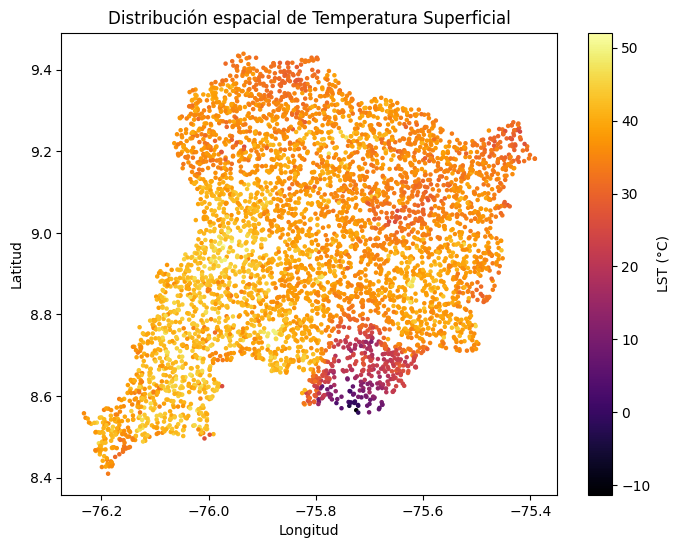

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["LST_C"],
    s=5,
    cmap="inferno"
)

plt.colorbar(label="LST (°C)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Distribución espacial de Temperatura Superficial")
plt.show()

# 6. Analisis de variables

##  6.1 Histogramas de variables

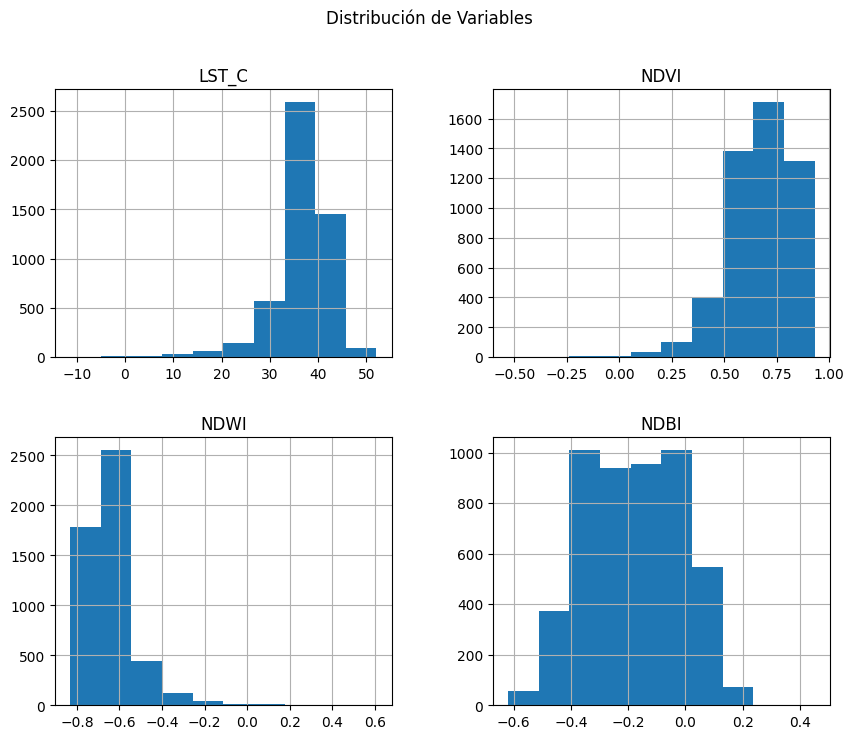

In [ ]:
# Histogramas de variables

df[[
    "LST_C",
    "NDVI",
    "NDWI",
    "NDBI"
]].hist(figsize=(10,8))

plt.suptitle("Distribución de Variables")
plt.show()


## 6.2 Matriz de correlación

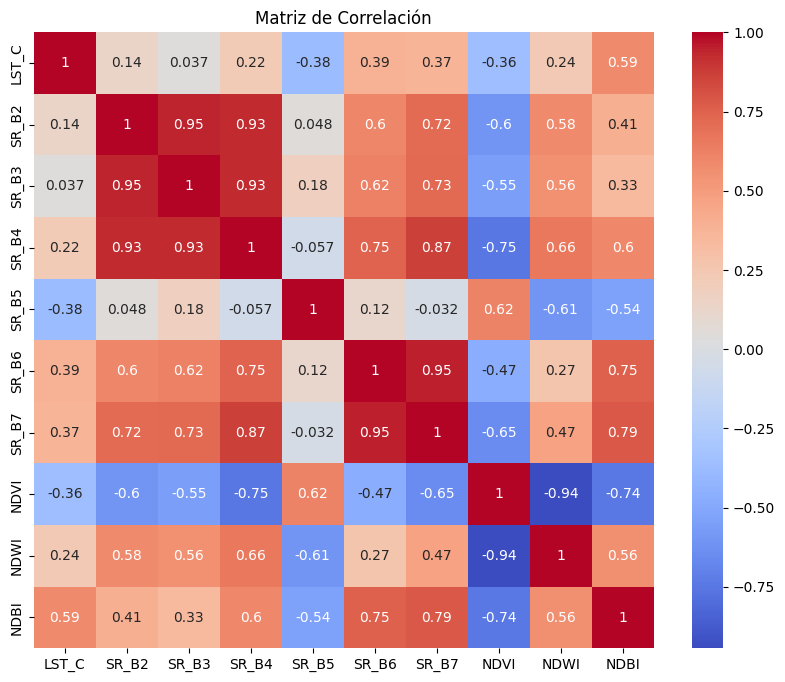

In [ ]:
# Matriz de correlación


plt.figure(figsize=(10,8))

sns.heatmap(
    df[[
        "LST_C",
        "SR_B2",
        "SR_B3",
        "SR_B4",
        "SR_B5",
        "SR_B6",
        "SR_B7",
        "NDVI",
        "NDWI",
        "NDBI"
    ]].corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Matriz de Correlación")
plt.show()

# 7. Preparación de variables para el modelo


##7.1 Preparación de variables predictoras y variable objetivo

In [ ]:
features = [
    "SR_B2",
    "SR_B3",
    "SR_B4",
    "SR_B5",
    "SR_B6",
    "SR_B7",
    "NDVI",
    "NDWI",
    "NDBI"
]

X = df[features]
y = df["LST_C"]

# Coordenadas espaciales

coords = df[["longitude", "latitude"]].values

## 7.2 Separación datos de entrenamiento/prueba (train/test)

In [ ]:
X_train, X_test, y_train, y_test, coords_train, coords_test = train_test_split(
    X,
    y,
    coords,
    test_size=0.3,
    random_state=42
)

print("\nDatos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)


Datos entrenamiento: (3481, 9)
Datos prueba: (1492, 9)


# 8. Modelo GPBoost

## 8.1 Definición del modelo GP Boost

GPBoost modela:

     y = F(X) + b(s) + e

donde:

   F(X)  -> efecto fijo aprendido por boosting,
   b(s)  -> efecto espacial (Gaussian Process),
   e     -> error residual

Las variables predictoras (NDVI, elevación, etc.) son modeladas con Tree Boosting, la autocorrelación espacial se modela con Gaussian Process.

In [ ]:
#Modelo
gp_model = gpb.GPModel(
    gp_coords=coords_train,
    cov_function="exponential"
)

[GPBoost] [Warning] The sparse matrix Z_ is created very inefficiently for this GP. This should be implemented more efficiently if n is large 


In [ ]:
# Dataset de entrenamiento
train_data = gpb.Dataset(
    X_train,
    label=y_train
)

Parámetros del modelo

In [ ]:
params = {
    "objective": "regression_l2",
    "learning_rate": 0.05,
    "max_depth": 3,
    "verbose": 1
}

Entrenamiento del modelo GP Boost

In [ ]:
bst = gpb.train(
    params=params,
    train_set=train_data,
    gp_model=gp_model,
    num_boost_round=30
)

print("\nModelo entrenado correctamente.")

gp_model.summary()  #parámetros espaciales estimados.



[GPBoost] [Info] Total Bins 2295
[GPBoost] [Info] Number of data points in the train set: 3481, number of used features: 9
[GPBoost] [Info] [GPBoost with gaussian likelihood]: initscore=36.689348
[GPBoost] [Info] Start training from score 36.689348

Modelo entrenado correctamente.
Model summary:
Nb. observations: 3481
Covariance parameters (random effects):
            Param.  Std. err.
Error_var   2.9668     0.1396
GP_var     76.3531    39.1455
GP_range    0.3596     0.1871


## 8.2 Predicción



In [ ]:
pred = bst.predict(
    data=X_test,
    gp_coords_pred=coords_test,
    predict_var=True,
    pred_latent=True
)

# Predicción final y=F(X)+b(s)
y_pred = pred["fixed_effect"] + pred["random_effect_mean"]

# Efecto fijo (boosting) - y=F(X)
fixed_effect = pred["fixed_effect"]

# Efecto espacial GP - b(s)
gp_effect = pred["random_effect_mean"]

# Covarianza espacial
gp_cov = pred["random_effect_cov"]

# Incertidumbre espacial
gp_std = np.sqrt(gp_cov)

## 8.3 Evaluación del Modelo

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMÉTRICAS")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


MÉTRICAS
RMSE: 2.24
R²: 0.858


GUARDAR MODELO GPBOOST

In [ ]:
# GUARDAR MODELO GPBOOST COMPLETO EN GOOGLE COLAB

import pickle
from google.colab import files



In [ ]:
import pickle
from google.colab import files

# Save the booster part of the model
booster_filename = "gpboost_booster.model"
bst.save_model(booster_filename)
print(f"Booster model guardado correctamente como: '{booster_filename}'")

# Note: The gp_model parameters are typically saved within the booster model
# when GPBoost's native save_model is used. If you needed to save specific
# GP model parameters separately, you would extract them (e.g., gp_model.get_cov_pars())
# and save them via pickle or another method.

# You can still save other metadata using pickle
metadata = {
    "features": X.columns.tolist()
}

metadata_filename = "gpboost_metadata.pkl"
with open(metadata_filename, "wb") as f:
    pickle.dump(metadata, f)
print(f"Metadatos guardados correctamente como: '{metadata_filename}'")

# Download automatically to your computer
files.download(booster_filename)
files.download(metadata_filename)

Booster model guardado correctamente como: 'gpboost_booster.model'
Metadatos guardados correctamente como: 'gpboost_metadata.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 9. Resultados

## 9.1 Gráfico observado vs predicho

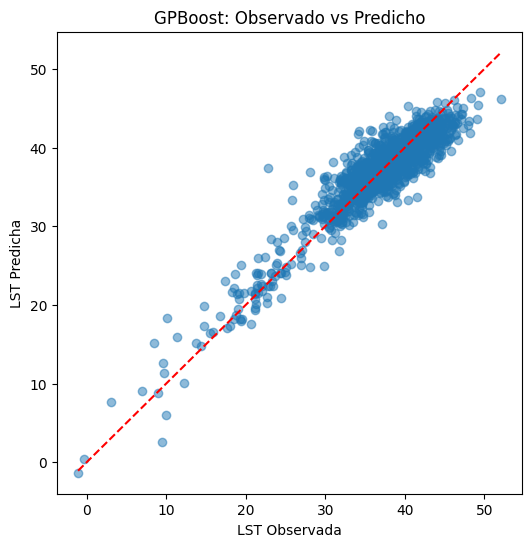

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("LST Observada")
plt.ylabel("LST Predicha")
plt.title("GPBoost: Observado vs Predicho")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## 9.2 Importancia de variables

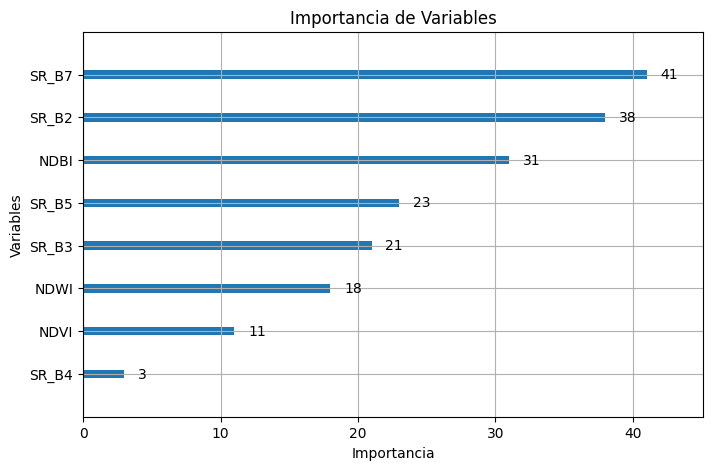

In [ ]:
gpb.plot_importance(bst, figsize=(8,5))

plt.ylabel("Variables")
plt.xlabel("Importancia")
plt.title("Importancia de Variables")
plt.show()

## 9.3 Visualización del efecto espacial GP Boost

Representa b(s) es decir, el efecto espacial residual estimado por el Gaussian Process.

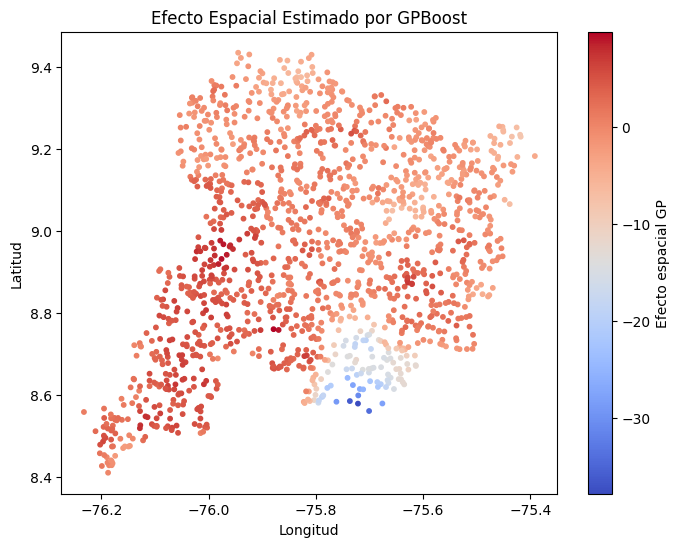

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    coords_test[:,0],
    coords_test[:,1],
    c=gp_effect,
    cmap="coolwarm",
    s=10
)

plt.colorbar(label="Efecto espacial GP")

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.title("Efecto Espacial Estimado por GPBoost")

plt.show()

## 9.4 Visualización de la incertidumbre espacial

Representa: e

incertidumbre espacial del GP o donde el modelo tiene menos confianza

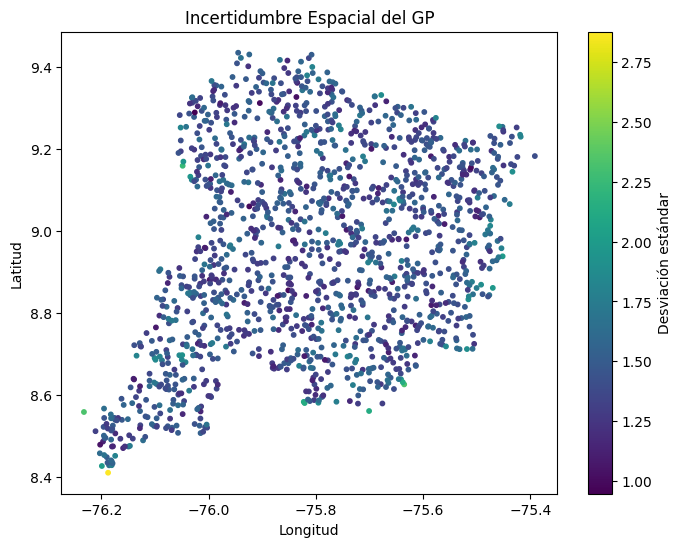

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    coords_test[:,0],
    coords_test[:,1],
    c=gp_std,
    cmap="viridis",
    s=10
)

plt.colorbar(label="Desviación estándar")

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.title("Incertidumbre Espacial del GP")

plt.show()

## 9.5 Visualización efecto fijo (Boosting)

Representa F(X) es decir:

Componente no lineal aprendida por boosting.  Solo usando las covariables, esta sería la temperatura esperada

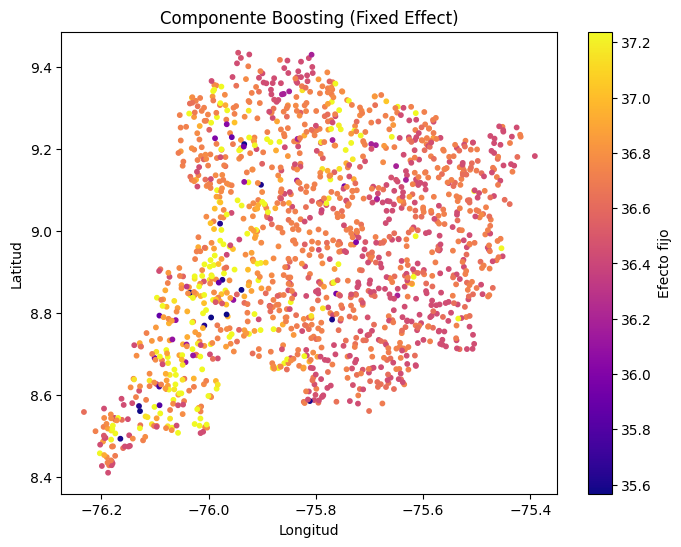

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    coords_test[:,0],
    coords_test[:,1],
    c=fixed_effect,
    cmap="plasma",
    s=10
)

plt.colorbar(label="Efecto fijo")

plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.title("Componente Boosting (Fixed Effect)")

plt.show()

#9.6 SHAP - Interpretación del modelo

In [ ]:
print("\nCalculando valores SHAP...")

explainer = shap.TreeExplainer(bst)

shap_values = explainer.shap_values(X_test)


Calculando valores SHAP...


##Gráfico resumen SHAP

/tmp/ipykernel_3484/219860562.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


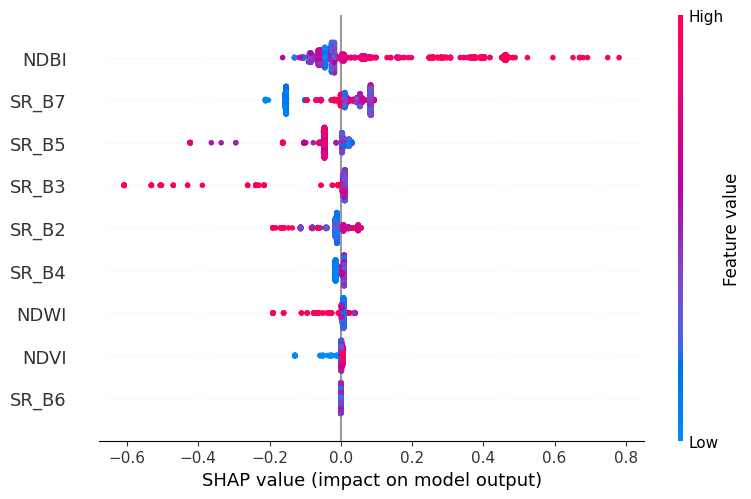

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

##Gráfico de dependencia SHAP - NDVI




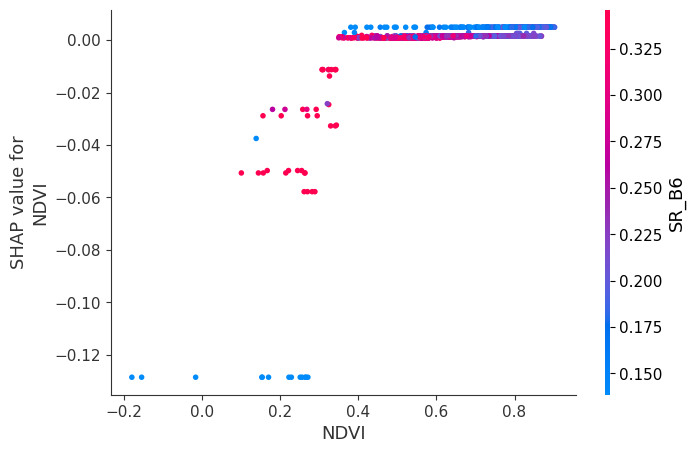

In [ ]:
shap.dependence_plot(
    "NDVI",
    shap_values,
    X_test
)


#9.7 Ajuste de Parámetros

Nota: Debido al alto costo computacional de los Gaussian Processes espaciales, no se realizo el ajuste de parámetros

In [ ]:
# Ajuste de hiperparámetros

param_grid = {
    'learning_rate': [0.1, 0.01],
    'max_depth': [3, 5],
    'min_data_in_leaf': [10, 20]
}

print("Iniciando ajuste de hiperparámetros...")



Iniciando ajuste de hiperparámetros...


In [ ]:
opt_params = gpb.grid_search_tune_parameters(
    param_grid=param_grid,
    params={
        "objective": "regression_l2",
        "verbose": 0
    },
    num_try_random=None,
    nfold=4,
    gp_model=gp_model,
    use_gp_model_for_validation=True,
    train_set=train_data,
    num_boost_round=100,
    early_stopping_rounds=10,
    metric="l2",
    seed=SEED
)

print("\nMejores parámetros encontrados:")
print(opt_params)

Starting deterministic grid search with 8 parameter combinations 
Trying parameter combination 1 of 8: {'learning_rate': np.float64(0.1), 'max_depth': np.int64(3), 'min_data_in_leaf': np.int64(10)}
[GPBoost] [Warning] The sparse matrix Z_ is created very inefficiently for this GP. This should be implemented more efficiently if n is large 
[GPBoost] [Warning] The sparse matrix Z_ is created very inefficiently for this GP. This should be implemented more efficiently if n is large 
[GPBoost] [Warning] The sparse matrix Z_ is created very inefficiently for this GP. This should be implemented more efficiently if n is large 
[GPBoost] [Warning] The sparse matrix Z_ is created very inefficiently for this GP. This should be implemented more efficiently if n is large 
[GPBoost] [Info] [GPBoost with gaussian likelihood]: initscore=36.675019
[GPBoost] [Info] Start training from score 36.675019
[GPBoost] [Info] [GPBoost with gaussian likelihood]: initscore=36.746914
[GPBoost] [Info] Start training

KeyboardInterrupt: 

# 9.8 Comparación de métricas contra otros modelos

###9.7.1 Modelo linear GP




In [ ]:
from sklearn.linear_model import LinearRegression

# Agregar intercepto
X_train_lin = np.column_stack((
    np.ones(len(X_train)),
    X_train
))

X_test_lin = np.column_stack((
    np.ones(len(X_test)),
    X_test
))



GP lineal

In [ ]:
gp_model_lin = gpb.GPModel(
    gp_coords=coords_train,
    cov_function="exponential"
)

[GPBoost] [Warning] The sparse matrix Z_ is created very inefficiently for this GP. This should be implemented more efficiently if n is large 


Ajuste

In [ ]:
gp_model_lin.fit(
    y=y_train,
    X=X_train_lin
)

Predicción

In [ ]:
pred_lin = gp_model_lin.predict(
    gp_coords_pred=coords_test,
    X_pred=X_test_lin
)

y_pred_lin = pred_lin["mu"]

Métricas

In [ ]:
rmse_lin = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lin
    )
)

r2_lin = r2_score(
    y_test,
    y_pred_lin
)
print("\nMÉTRICAS")
print(f"RMSE GP lineal: {rmse_lin:.2f}")
print(f"R² GP lineal: {r2_lin:.3f}")

###9.7.2 Modelo Boost sin Gaussian Process

Agregar coordenadas como variables


In [ ]:

print("\nEntrenando Gradient Boosting...")

# Agregar coordenadas como variables
X_train_boost = np.column_stack((
    X_train,
    coords_train
))

X_test_boost = np.column_stack((
    X_test,
    coords_test
))



Entrenando Gradient Boosting...


Dataset

In [ ]:
train_boost = gpb.Dataset(
    X_train_boost,
    label=y_train
)

Entrenamiento

In [ ]:
bst_boost = gpb.train(
    params=params,
    train_set=train_boost,
    num_boost_round=250
)



[GPBoost] [Info] Total Bins 2805
[GPBoost] [Info] Number of data points in the train set: 3481, number of used features: 11
[GPBoost] [Info] Start training from score 36.689348


Predicción

In [ ]:
pred_boost = bst_boost.predict(X_test_boost)

Métricas

In [ ]:
rmse_boost = np.sqrt(
    mean_squared_error(
        y_test,
        pred_boost
    )
)

r2_boost = r2_score(
    y_test,
    pred_boost
)

print(f"RMSE Boosting: {rmse_boost:.3f}")
print(f"R² Boosting: {r2_boost:.3f}")

RMSE Boosting: 2.562
R² Boosting: 0.815


### 9.7.3 RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Modelo RF

In [ ]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    random_state=SEED,
    n_jobs=-1
)

Entrenamiento

In [ ]:
rf.fit(
    X_train_boost,
    y_train
)

RandomForestRegressor(max_depth=20, n_estimators=500, n_jobs=-1,
                      random_state=42)

Predicción

In [ ]:
pred_rf = rf.predict(X_test_boost)

Métricas

In [ ]:
rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    pred_rf
)
print("\nMÉTRICAS")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²: {r2_rf:.3f}")

#9.9 Comparación de resultados



Tabla de resultados de metricas

In [ ]:
results = pd.DataFrame({
    "Modelo": [
        "Linear GP",
        "Boosting",
        "Random Forest",
        "GPBoost"
    ],
    "RMSE": [
        rmse_lin,
        rmse_boost,
        rmse_rf,
        rmse
    ],
    "R2": [
        r2_lin,
        r2_boost,
        r2_rf,
        r2
    ]
})

print("\n========== COMPARACIÓN MODELOS ==========")
display(results)


========== COMPARACIÓN MODELOS ==========


,Modelo,RMSE,R2
0,Linear GP,1.905004,0.897860
1,Boosting,2.561611,0.815316
2,Random Forest,2.357483,0.843577
3,GPBoost,2.243349,0.858356


Gráfico comparativo

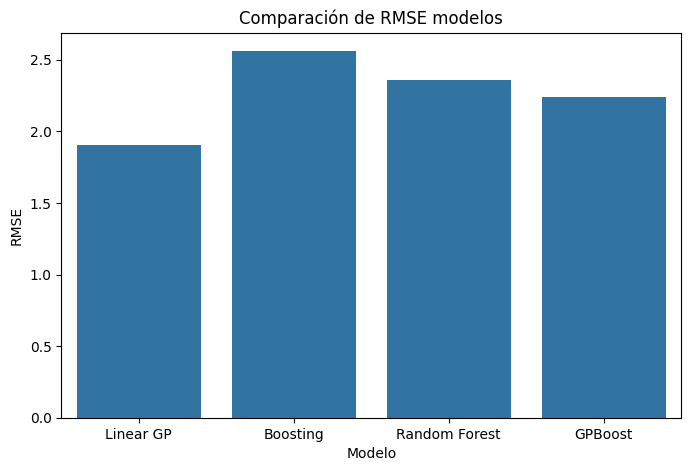

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Modelo",
    y="RMSE"
)

plt.title("Comparación de RMSE modelos")

plt.ylabel("RMSE")

plt.show()

#10. Discusión

El modelo GPBoost aplicado a la cuenca del río Sinú permitió estimar la temperatura superficial terrestre a partir de variables espectrales Landsat e índices derivados. El desempeño obtenido fue RMSE = 2.24 °C y R² = 0.858, lo que indica una relación consistente entre los valores observados y predichos de LST.

La gráfica observado vs. predicho muestra que la mayoría de puntos se concentran cerca de la línea 1:1, aunque existe dispersión en valores bajos y altos de temperatura. Esto puede estar asociado a variabilidad local no capturada completamente por las bandas espectrales, diferencias entre coberturas, presencia de agua, nubes residuales o mezcla espectral.

La importancia de variables muestra mayor contribución de SR_B7, SR_B2 y NDBI. Esto sugiere que las bandas del infrarrojo de onda corta, la banda azul y el índice construido con SWIR y NIR aportan información relevante para explicar variaciones de LST en el área de estudio. El resultado es coherente con la sensibilidad de la temperatura superficial a condiciones de humedad, vegetación, suelo expuesto y superficies construidas.

#Conclusiones

La aplicación con datos Landsat de la cuenca del río Sinú muestra que GPBoost puede utilizarse en problemas de percepción remota cuando existe una variable continua de interés y coordenadas espaciales asociadas a cada observación.

El modelo alcanzó un R² de 0.858 y un RMSE de 2.24 °C, por lo que logró explicar una parte considerable de la variabilidad espacial de la temperatura superficial terrestre.

La incorporación de coordenadas mediante el componente Gaussian Process permite considerar dependencia espacial, aspecto que no se modela explícitamente en algoritmos convencionales de machine learning.

Debido al costo computacional del componente espacial en el proceso Gausiano, en aplicaciones con grandes volúmenes de píxeles se recomienda usar submuestreo espacial, reducción de resolución o partición por zonas. Debido al alto costo computacional del componente Gaussian Process, en aplicaciones a gran escala puede ser conveniente aplicar técnicas de submuestreo espacial.

